## Image Segmentation

In [ ]:
!pip install ultralytics opencv-python

In [ ]:
import cv2, numpy as np
from ultralytics import YOLO
import matplotlib.pyplot as plt
import os

IMG_PAHT = 'animal.jpg'
OUT_DIR = 'seg_output'
os.makedirs(OUT_DIR, exist_ok=True)

In [ ]:
model = YOLO("yolo11n-seg.pt")

im_bgr = cv2.imread(IMG_PAHT)
assert im_bgr is not None, f'이미지 읽기 실패 : {IMG_PAHT}' # 이미지가 없으면 날려라.
print(im_bgr.shape) # (1279, 1920, 3)

# H, W 얻기
H, W = im_bgr.shape[:2]

print(H, W)

(1279, 1920, 3)
1279 1920


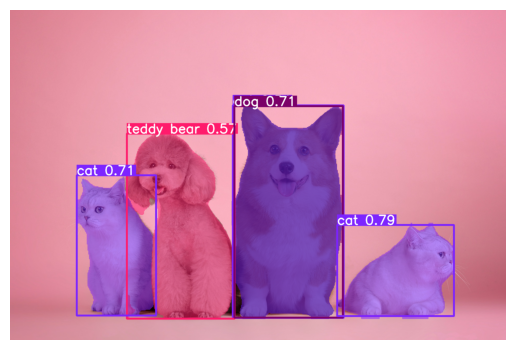

In [ ]:
res = model(im_bgr, verbose=False)[0] # 한장의 세그멘테이션 결과를 얻음

# 이미지 저장
annotated = res.plot() # box라벨 마스크를 그림
cv2.imwrite(os.path.join(OUT_DIR, '8_10yolo_segmentation_result.jpg'), annotated)

# 화면 시각화 하기
plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

In [ ]:
# pytorch Tensor -> numpy arr로 변환하기(마스크가 있을때 작업)
has_masks = (res.masks is not None)

if has_masks:
  # cpu() : GPU가 있는데 GPU를 안쓰고 CPU연산을 사용 하고 싶을 때 사용
  masks_np = res.masks.data.cpu().numpy()
  boxes_np = res.boxes.xyxy.cpu().numpy().astype(int) # 경계박스좌표 소수를 int로 변경
  conf_np = res.boxes.conf.cpu().numpy()              # 신뢰도 점수
  class_np = res.boxes.cls.cpu().numpy().astype(int)  # 라벨 이름
  print(masks_np.shape, boxes_np.shape, conf_np.shape, class_np.shape)

else:
  masks_np = boxes_np = conf_np = class_np = None

(5, 448, 640) (5, 4) (5,) (5,)


In [ ]:
# mask 오버레이 작업

overlay = im_bgr.copy() # 원본 이미지 복사

# Instance Segmentation
if has_masks:
  for m in masks_np: # mask 배열
    # 모델이 출력한 마스크 크기(H, W)를 원본크기로 리사이즈하기
      #-> interpolation=cv2.INTER_NEAREST : 경계를 매끄럽게 만들어주는 옵션
      #-> 0.5 이상일 때만 객체로 간주(이진화 처리(T/F))
    m_bin = cv2.resize(m, (W, H), interpolation=cv2.INTER_NEAREST) > 0.5
    # print(m_bin) # [[False False ...

    # mask를 위해 원본이미지와 동일한 0으로 채워진(Black) 빈 배열(공간) 생성
    color_mask = np.zeros_like(overlay)
    # True값 인 곳(mask부분)만 색을 넣어줌 - 객체 마스크 px만 (0, 255, 0)색으로 채움
    color_mask[m_bin] = (0, 255, 0)

    # 두 이미지 합성하기
      #-> cv2.addWeighted(이미지1, 이미지1 비율(가중치), 이미지2, 이미지2 비율(가중치), 추가 밝기 조절)
      #-> OpenCV에서 두 이미지를 가중치를 적용해 합성(블렌딩)하는 함수
      #-> 두 가중치의 합은 1을 넘지 않도록 설정하는 것이 일반적
    overlay = cv2.addWeighted(overlay, 1, color_mask, 0.7, 0.0)

cv2.imwrite(os.path.join(OUT_DIR, '8_10yolo_segmentation_overlay.jpg'), overlay)


True

### Instance Segmentation


- 인스턴스 세그먼테이션(Instance Segmentation)은 이미지 내의 각 개체를 개별적으로 구분하고 분할하는 고급 이미지 처리 기술

In [ ]:
# 객체별 배경 제거 후 PNG로 따로따로 저장 - Semantic Segmentation(세그먼테이션)만 가능한 작업

crops_dir = os.path.join(OUT_DIR,'seg_crops')
os.makedirs(crops_dir, exist_ok=True) # 하위 폴더 생성

# YOLO 출력 마스크를 원본 이미지 크기에 맞게 변한 후 여러 객체 마스크를 처리
if has_masks and len(masks_np) > 0: # 마스크 결과가 있고 크기가 1개 이상인 경우 실행
  # 마스크들을 축으로 쌓을것임 : Stack(3, , )
  masks_full = np.stack(
      [cv2.resize(m, (W, H), interpolation=cv2.INTER_NEAREST) > 0.5 for m in masks_np],
      axis=0
  )

  # 탐지된 객체의 배경을 제거해 PNG로 저장하기
  # 인스턴스 순회
  for i, (m_full, box, cls_id, conf) in enumerate(zip(masks_full, boxes_np, class_np, conf_np)):
    x1, y1, x2, y2 = map(int, box) # 박스좌표 정수형으로 받기
    # 보정작업하기
    x1, y1 = max(0, x1), max(0, y1) # 좌 상단 좌표가 이미지 밖으로 나가면 0으로 보정
    x2, y2 = min(W, x2), min(H, y2) # 우 하단 좌표가 이미지 밖으로 나가면 (W, H)으로 보정
    # 잘못된 box정보(좌표)는 건너 뜀
    if x2 <= x1 or y2 <= y1:
      continue

    # openCV는 이미지 순서가 [행(H), 열(W), Channel] 이므로 이미지 자를 때 주의를 해야함!
    crop_bgr = im_bgr[y1:y2, x1:x2] # 원본 이미지에서 박스 영역만 자름 [행(H), 열(W)]로 잘라야함!
    crop_mask = (m_full[y1:y2, x1:x2] * 255).astype(np.uint8) # 같은 영역 마스크를 0/255(불투명)로 변환 <- alpha로 사용하기 위해

    crop_bgra = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2BGRA) # cv2.COLOR_BGR2BGRA: Alpah 채널 추가(4채널)
    # [..., 3] : 앞(3차원)은 그대로 두고 4번째(Alpha 채널)에 마스크 적용 -> 배경은 투명, 객체는 불투명해짐(PNG)
    crop_bgra[..., 3] = crop_mask

    # 클래스 이름 얻기(dog, cat ...)
    name = model.names[int(cls_id)] if hasattr(model, 'names') else str(cls_id)
    cv2.imwrite(os.path.join(crops_dir, f'crop_{i}_{name}_{conf:.2f}.png'), crop_bgra)

### Semantic Segmentation (의미론적 세그먼테이션)
- semantic segmentation은 pixel들이 각 class에 대해 binary하게 포함되는지 안되는지 여부만 따진다.

In [ ]:
sem_canvas = np.zeros((H, W, 3), dtype=np.uint8)  # 검정으로 채운 색상 지도
conf_map = np.zeros((H, W), dtype=np.float32)     # 신뢰도를 기록할 map

# 객채별 색상 선택하기 - YOLO에서 주로 사용하는 계산식(숫자는 소숫값을 사용)
def class_color(c:int):
  return((37 * c) % 256, (17 * c) % 256, (91 * c) % 256) # BGR 형태의 색상을 반환함

if has_masks and len(masks_np) > 0:
  for m_full, cls_id, conf in zip(masks_full, class_np, conf_np):
    color = class_color(int(cls_id))    # 클래스별 고정 색상 생성하기
    update = m_full & (conf > conf_map) # 이번 인스턴스의 conf가 더 큰 픽셀만 갱신  = 현재 저장된 신뢰도보다 더 높은 신뢰도 값이 있을때만 신뢰도값 갱신
    sem_canvas[update] = color # 해당 인스턴스의 색을 color값으로 채움
    conf_map[update] = conf    # 해당 인스턴스의 최고 신뢰도를 현재 인스턴스의 conf로 갱신

cv2.imwrite(os.path.join(OUT_DIR, '8_10yolo_segmentation_semantic.jpg'), sem_canvas)

True